# Portfolio ML - Summary Dashboard

Notebook de seguimiento interactivo del pipeline completo en **paper**:

- Data fetch y limpieza
- Feature panel y entrenamiento walk-forward
- Backtest, riesgo y diagnosticos factoriales
- Recomendacion automatica de estrategia/pesos (`run_all`)
- Comparativa reciente `market_neutral` vs `long_only`


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')
pd.options.display.max_columns = 200
pd.options.display.width = 140


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'configs').exists() and (p / 'src').exists():
            return p
    raise RuntimeError('No se pudo detectar la raiz del proyecto.')

ROOT = find_project_root()
PATHS = {
    'raw': ROOT / 'data/raw/prices.parquet',
    'clean': ROOT / 'data/processed/prices_clean.parquet',
    'panel': ROOT / 'data/processed/panel.parquet',
    'train_summary': ROOT / 'outputs/models/train_summary.json',
    'predictions': ROOT / 'outputs/models/predictions_oos.parquet',
    'training_log': ROOT / 'outputs/models/training_log.parquet',
    'feature_importance': ROOT / 'outputs/models/feature_importance.parquet',
    'backtest_summary': ROOT / 'outputs/backtests/backtest_summary.json',
    'daily_returns': ROOT / 'outputs/backtests/daily_returns.parquet',
    'rebalance_log': ROOT / 'outputs/backtests/rebalance_log.parquet',
    'weights_history': ROOT / 'outputs/backtests/weights_history.parquet',
    'subperiod_report': ROOT / 'outputs/backtests/subperiod_report.json',
    'factor_exposure_report': ROOT / 'outputs/backtests/factor_exposure_report.json',
    'factor_diagnostics_report': ROOT / 'outputs/backtests/factor_diagnostics_report.json',
}

print(f'Project root: {ROOT}')

Project root: /Users/jenriquezafra/Proyectos/Dev/python/portfolio


In [3]:
status = []
for name, path in PATHS.items():
    status.append({
        'artifact': name,
        'exists': path.exists(),
        'path': str(path),
        'size_kb': round(path.stat().st_size / 1024, 2) if path.exists() else None,
    })

status_df = pd.DataFrame(status).sort_values('artifact').reset_index(drop=True)
display(status_df)

,artifact,exists,path,size_kb
0,backtest_summary,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,2.00
1,clean,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,3837.67
2,daily_returns,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,63.74
3,factor_diagnostics_report,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,1.22
4,factor_exposure_report,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,0.14
5,feature_importance,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,17.14
6,panel,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,27248.82
7,predictions,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,81.63
8,raw,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,3841.27
9,rebalance_log,True,/Users/jenriquezafra/Proyectos/Dev/python/port...,20.53


## 1) Raw Data (descarga)

Shape: (127600, 8)
Date range: 2016-01-04 -> 2026-02-26
Tickers: 50
Missing % by column:


,pct_missing
date,0.00
ticker,0.00
open,6.97
high,6.97
low,6.97
close,6.97
adj_close,6.97
volume,6.97


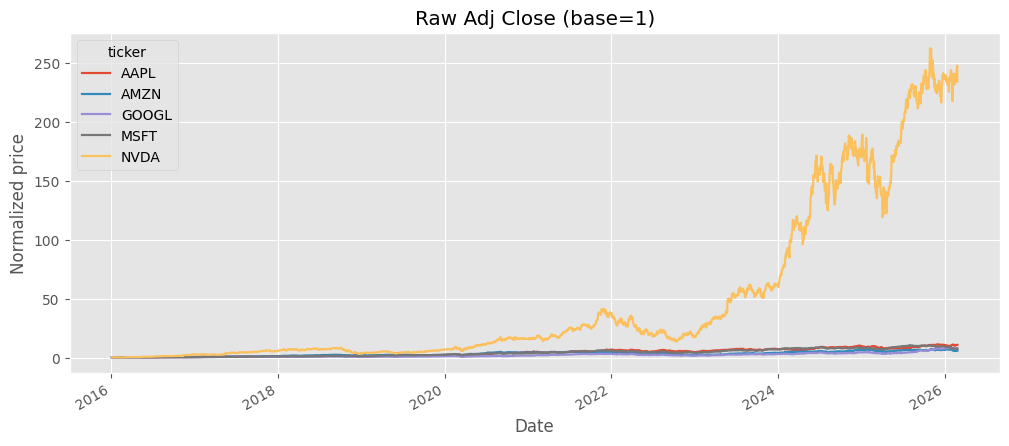

In [4]:
raw = pd.read_parquet(PATHS['raw'])
raw['date'] = pd.to_datetime(raw['date'])

print('Shape:', raw.shape)
print('Date range:', raw['date'].min().date(), '->', raw['date'].max().date())
print('Tickers:', raw['ticker'].nunique())
print('Missing % by column:')
display((raw.isna().mean() * 100).round(2).rename('pct_missing').to_frame())

sample_tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL']
plot_df = raw[raw['ticker'].isin(sample_tickers)].pivot(index='date', columns='ticker', values='adj_close').sort_index()
norm = plot_df / plot_df.ffill().bfill().iloc[0]

ax = norm.plot(figsize=(12, 5), linewidth=1.6, title='Raw Adj Close (base=1)')
ax.set_ylabel('Normalized price')
ax.set_xlabel('Date')
plt.show()

## 2) Clean Data + Feature Panel

Clean shape: (118706, 8)
Panel shape: (114806, 29)
Panel date range: 2016-04-05 -> 2026-02-04
Panel tickers: 50


,count,mean,std,min,max
date,114806,2021-05-15 21:55:38.229709312,NaN,2016-04-05 00:00:00,2026-02-04 00:00:00
ticker,114806,NaN,NaN,NaN,NaN
adj_close,114806.0,144.58659,154.01969,0.850975,1682.523682
volume,114806.0,25893212.380015,79504293.873086,74500.0,3692928000.0
ret_1d,114806.0,0.001172,0.025955,-0.358373,0.522901
ret_2d,114806.0,0.00232,0.035829,-0.374028,0.560564
ret_5d,114806.0,0.005833,0.056175,-0.439283,1.033165
ret_10d,114806.0,0.011657,0.077616,-0.570808,1.042644
ret_20d,114806.0,0.023432,0.109068,-0.638977,1.128143
ret_63d,114806.0,0.075941,0.198641,-0.648312,2.919598


Target column used for panel diagnostics: fwd_return_raw


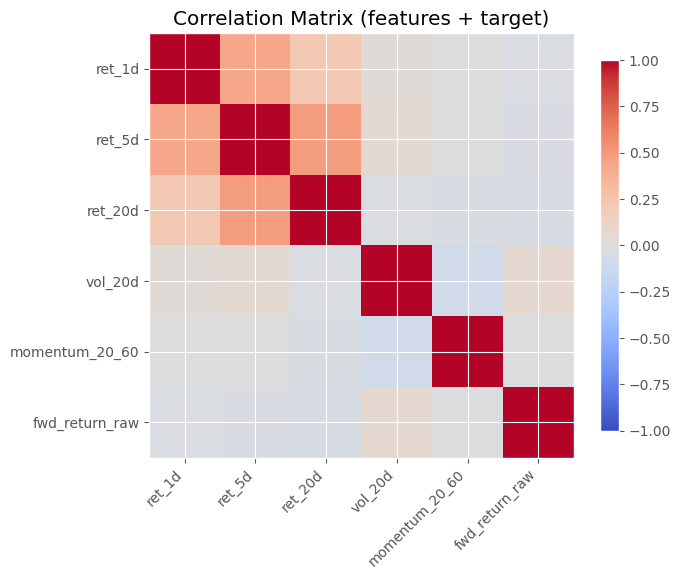

In [5]:
clean = pd.read_parquet(PATHS['clean'])
panel = pd.read_parquet(PATHS['panel'])
clean['date'] = pd.to_datetime(clean['date'])
panel['date'] = pd.to_datetime(panel['date'])

print('Clean shape:', clean.shape)
print('Panel shape:', panel.shape)
print('Panel date range:', panel['date'].min().date(), '->', panel['date'].max().date())
print('Panel tickers:', panel['ticker'].nunique())

display(panel.describe(include='all').T[['count', 'mean', 'std', 'min', 'max']].head(12))

features = ['ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'momentum_20_60']
target_candidates = ['fwd_return_5d_resid', 'fwd_return_5d', 'fwd_return_raw']
target_col = next((c for c in target_candidates if c in panel.columns), None)
if target_col is None:
    raise KeyError(f'No target column found in panel. Expected one of: {target_candidates}')
print('Target column used for panel diagnostics:', target_col)
corr = panel[features + [target_col]].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlation Matrix (features + target)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3) Walk-Forward XGBoost

,value
avg_validation_ic_spearman,0.040656
date_end,2026-01-14
date_start,2017-06-12
features,"[ret_1d, ret_2d, ret_5d, ret_10d, ret_20d, ret..."
horizon_days,15
model_params,"{'colsample_bytree': 0.75, 'learning_rate': 0...."
n_predictions,5136
n_rebalances,109
oos_cs_ic_ir,0.297421
oos_cs_ic_mean,0.056245


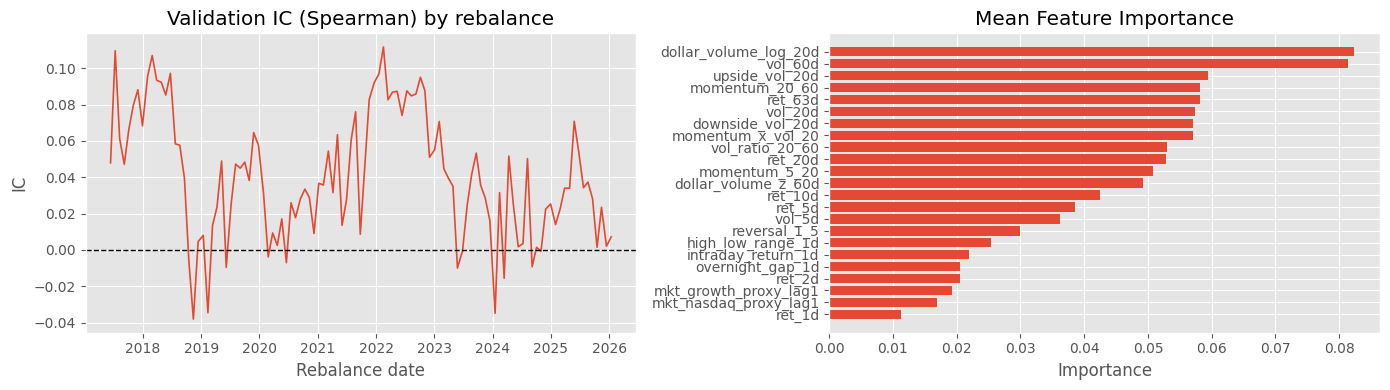

OOS IC recomputed: 0.039252 | target: fwd_return_15d_resid


In [6]:
with PATHS['train_summary'].open('r', encoding='utf-8') as fh:
    train_summary = json.load(fh)

training_log = pd.read_parquet(PATHS['training_log'])
feature_importance = pd.read_parquet(PATHS['feature_importance'])
pred = pd.read_parquet(PATHS['predictions'])

training_log['rebalance_date'] = pd.to_datetime(training_log['rebalance_date'])

display(pd.DataFrame([train_summary]).T.rename(columns={0: 'value'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(training_log['rebalance_date'], training_log['validation_ic_spearman'], linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Validation IC (Spearman) by rebalance')
axes[0].set_xlabel('Rebalance date')
axes[0].set_ylabel('IC')

fi = feature_importance.groupby('feature', as_index=False)['importance'].mean().sort_values('importance')
axes[1].barh(fi['feature'], fi['importance'])
axes[1].set_title('Mean Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

target_col = train_summary.get('target_column', 'fwd_return_5d')
if target_col not in pred.columns:
    raise KeyError(f'Target column {target_col!r} not found in predictions file.')
oos_ic = pred['prediction'].corr(pred[target_col], method='spearman')
print('OOS IC recomputed:', round(float(oos_ic), 6), '| target:', target_col)

## 4) Backtest, Riesgo y Cartera

,value
allocation_method,mean_variance
annualized_return,0.462589
annualized_volatility,0.311108
average_gross_exposure,0.898826
average_net_exposure,0.898826
average_overlay_leverage,1.0
average_signal_gate_multiplier,0.915596
average_turnover,0.344706
beta_neutralization_enabled,False
end_date,2026-02-26


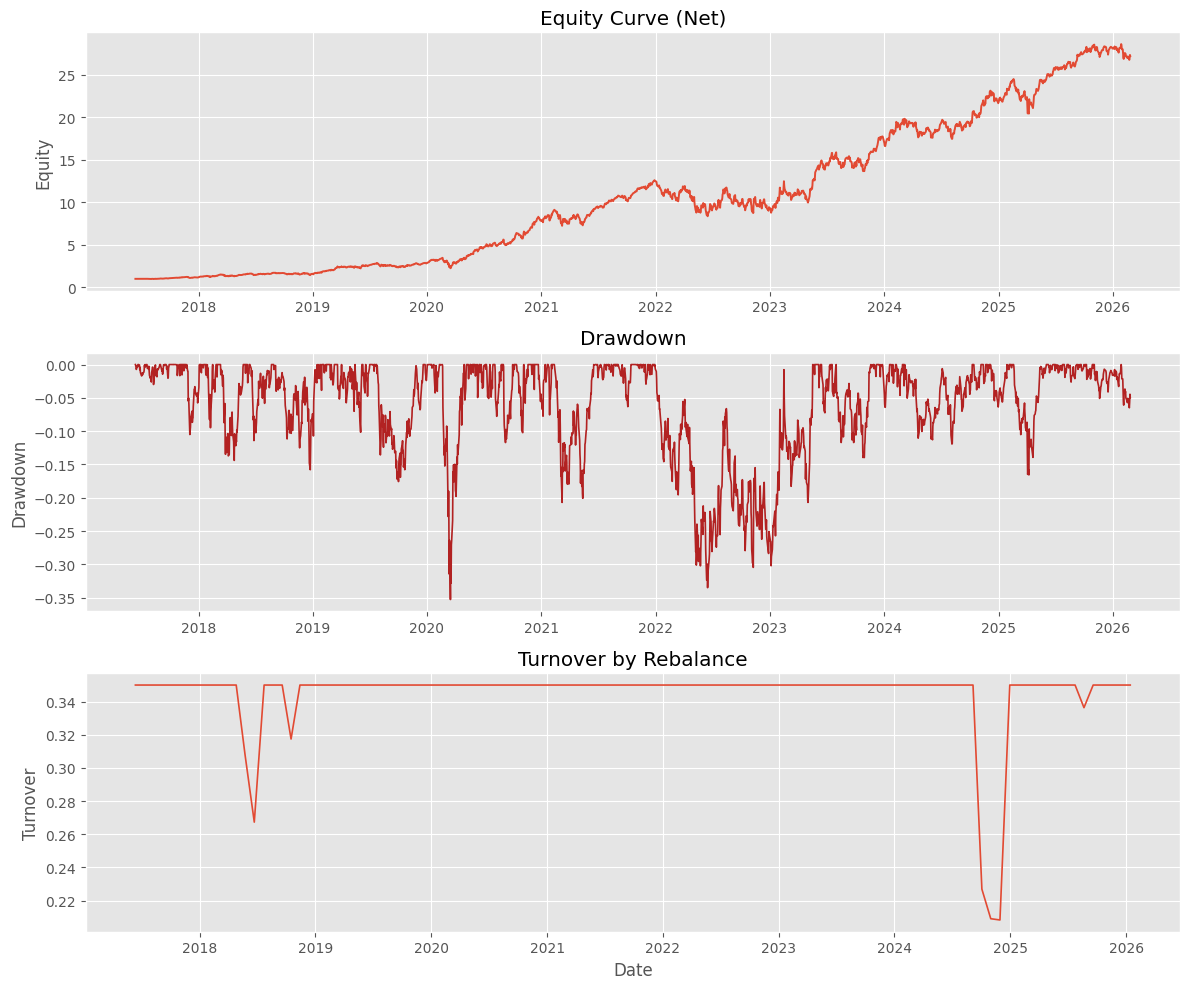

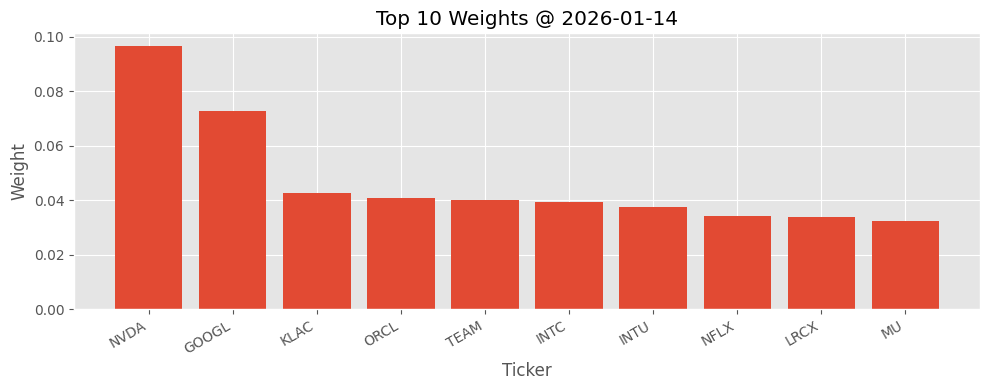

,rebalance_date,ticker,weight,predicted_return,signal_score
0,2026-01-14,NVDA,0.096407,-0.000611,-0.226071
1,2026-01-14,GOOGL,0.072851,-0.000611,-0.211564
2,2026-01-14,KLAC,0.042570,0.003325,2.816815
3,2026-01-14,ORCL,0.040846,-0.000611,-0.240578
4,2026-01-14,TEAM,0.040069,-0.000611,-0.308275
5,2026-01-14,INTC,0.039350,0.001533,2.569889
6,2026-01-14,INTU,0.037463,0.003325,2.628230
7,2026-01-14,NFLX,0.034118,-0.000611,-0.274426
8,2026-01-14,LRCX,0.033778,0.001533,2.569889
9,2026-01-14,MU,0.032498,0.001533,2.569889


In [7]:
with PATHS['backtest_summary'].open('r', encoding='utf-8') as fh:
    backtest_summary = json.load(fh)

daily = pd.read_parquet(PATHS['daily_returns'])
rebalance_log = pd.read_parquet(PATHS['rebalance_log'])
weights = pd.read_parquet(PATHS['weights_history'])

daily['date'] = pd.to_datetime(daily['date'])
rebalance_log['rebalance_date'] = pd.to_datetime(rebalance_log['rebalance_date'])
weights['rebalance_date'] = pd.to_datetime(weights['rebalance_date'])

display(pd.DataFrame([backtest_summary]).T.rename(columns={0: 'value'}))

equity = (1 + daily['portfolio_return_net']).cumprod()
rolling_max = equity.cummax()
drawdown = equity / rolling_max - 1

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
axes[0].plot(daily['date'], equity, linewidth=1.4)
axes[0].set_title('Equity Curve (Net)')
axes[0].set_ylabel('Equity')

axes[1].plot(daily['date'], drawdown, color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')

axes[2].plot(rebalance_log['rebalance_date'], rebalance_log['turnover'], linewidth=1.2)
axes[2].set_title('Turnover by Rebalance')
axes[2].set_ylabel('Turnover')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

latest_reb = weights['rebalance_date'].max()
latest_w = weights[weights['rebalance_date'] == latest_reb].sort_values('weight', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(latest_w['ticker'], latest_w['weight'])
ax.set_title(f'Top 10 Weights @ {latest_reb.date()}')
ax.set_ylabel('Weight')
ax.set_xlabel('Ticker')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

display(latest_w.reset_index(drop=True))

## 5) Diagnostico Factorial Automatico

Lectura automatica de exposiciones ex-ante/ex-post y flags de control.


In [8]:
with PATHS['factor_exposure_report'].open('r', encoding='utf-8') as fh:
    factor_exposure = json.load(fh)

if PATHS['factor_diagnostics_report'].exists():
    with PATHS['factor_diagnostics_report'].open('r', encoding='utf-8') as fh:
        factor_diag = json.load(fh)
else:
    factor_diag = None

factor_names = factor_exposure.get('factor_names', [])
print('Factor names:', factor_names)

if factor_diag is None:
    print('No existe factor_diagnostics_report.json. Ejecuta scripts/03_backtest.py o scripts/05_report.py.')
else:
    print('Diagnostics status:', factor_diag.get('status'))
    checks = pd.DataFrame([
        {'check': k, 'ok': bool(v)} for k, v in (factor_diag.get('checks') or {}).items()
    ])
    if not checks.empty:
        display(checks)

full_sample = (factor_exposure.get('ex_post') or {}).get('full_sample') or {}
full_betas = (full_sample.get('betas') or {})
if full_betas:
    betas_df = pd.DataFrame([{'factor': k, 'beta': v} for k, v in full_betas.items()]).sort_values('factor')
    display(betas_df.reset_index(drop=True))

by_year = (factor_exposure.get('ex_post') or {}).get('by_year') or []
if by_year:
    yearly_rows = []
    for row in by_year:
        base = {
            'year': row.get('year'),
            'n_obs': row.get('n_obs'),
            'alpha_daily': row.get('alpha_daily'),
            'r2': row.get('r2'),
        }
        betas = row.get('betas') or {}
        for name, value in betas.items():
            base[f'beta_{name}'] = value
        yearly_rows.append(base)

    yearly_df = pd.DataFrame(yearly_rows).sort_values('year')
    display(yearly_df)

    beta_cols = [c for c in yearly_df.columns if c.startswith('beta_')]
    if beta_cols:
        fig, ax = plt.subplots(figsize=(12, 4))
        for col in beta_cols:
            ax.plot(yearly_df['year'], yearly_df[col], marker='o', linewidth=1.2, label=col.replace('beta_', ''))
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        ax.set_title('Ex-post factor betas by year')
        ax.set_xlabel('Year')
        ax.set_ylabel('Beta')
        ax.legend(loc='best')
        plt.tight_layout()
        plt.show()

if factor_diag is not None:
    recs = factor_diag.get('recommendations') or []
    if recs:
        print('Recommendations:')
        for rec in recs:
            print('-', rec)


Factor names: []
Diagnostics status: missing_factors


,check,ok
0,ex_ante_max_abs_ok,True
1,ex_ante_mean_abs_ok,True
2,ex_post_beta_abs_ok,True
3,ex_post_beta_yearly_abs_ok,True
4,ex_post_r2_ok,True


Recommendations:
- No factor diagnostics available. Enable beta_neutralization factors in backtest config.


## 6) Checklist Rapido

- Si falta algun artefacto, ejecutar scripts en orden: `00 -> 01 -> 02 -> 03 -> 05`.
- Para comparativas recientes, revisar `outputs/experiments/step10_*` y `step11_*`.
- En paper, usar `scripts/06_run_all.py` para obtener estrategia/pesos recomendados.


## 7) Strategy Recommendation (run_all)

Lectura del ultimo reporte generado por `scripts/06_run_all.py` para ver la estrategia sugerida y los pesos a seguir en paper.


In [9]:
run_all_dir = ROOT / 'outputs/run_all'
rec_path = run_all_dir / 'recommendation.json'

if not rec_path.exists():
    print('No existe recommendation.json aun. Ejecuta: python scripts/06_run_all.py')
else:
    with rec_path.open('r', encoding='utf-8') as fh:
        rec = json.load(fh)

    print('Recommendation file:', rec_path.name)
    print('Generated at (UTC):', rec.get('generated_at_utc'))
    print('Recommended strategy:', rec.get('recommended_strategy'))

    strategy_scores = pd.DataFrame([rec.get('strategy_scores', {})]).T.rename(columns={0: 'score'})
    display(strategy_scores.sort_values('score', ascending=False))

    ws = rec.get('weights_snapshot', {})
    print('Rebalance date:', rec.get('rebalance_date'))
    print('n_positions:', ws.get('n_positions'))
    print('gross_exposure:', ws.get('gross_exposure'))
    print('net_exposure:', ws.get('net_exposure'))

    top_longs = pd.DataFrame(ws.get('top_longs') or [])
    top_shorts = pd.DataFrame(ws.get('top_shorts') or [])
    if not top_longs.empty:
        print('Top longs:')
        display(top_longs)
    if not top_shorts.empty:
        print('Top shorts:')
        display(top_shorts)

    csv_path = Path((rec.get('artifacts') or {}).get('recommended_weights_csv', ''))
    if csv_path and csv_path.exists():
        rec_weights = pd.read_csv(csv_path)
        display(rec_weights.head(20))


Recommendation file: recommendation.json
Generated at (UTC): 2026-02-26T23:27:44+00:00
Recommended strategy: long_only


,score
long_only,1.285145
market_neutral,0.909137


Rebalance date: 2026-01-14
n_positions: 50
gross_exposure: 0.8102725034395296
net_exposure: 0.8102725034395296
Top longs:


,ticker,weight
0,AAPL,0.140841
1,ORCL,0.126258
2,PANW,0.084015
3,TSM,0.071465
4,GOOGL,0.069301
5,MSFT,0.069168
6,DDOG,0.047952
7,META,0.023389
8,NOW,0.020752
9,MCHP,0.018762


,ticker,weight
0,AAPL,0.140841
1,ORCL,0.126258
2,PANW,0.084015
3,TSM,0.071465
4,GOOGL,0.069301
5,MSFT,0.069168
6,DDOG,0.047952
7,META,0.023389
8,NOW,0.020752
9,MCHP,0.018762


## 8) Market-Neutral vs Long-Only (latest tuning)

Comparativa de los mejores resultados recientes de:

- `outputs/experiments/step10_mn_tuning_h7_wide/top10.json`
- `outputs/experiments/step11_long_only_h7/comparison.json`


In [10]:
mn_top_path = ROOT / 'outputs/experiments/step10_mn_tuning_h7_wide/top10.json'
lo_cmp_path = ROOT / 'outputs/experiments/step11_long_only_h7/comparison.json'

if not mn_top_path.exists() or not lo_cmp_path.exists():
    print('Faltan archivos de comparativa. Corre los experimentos step10/step11 primero.')
else:
    with mn_top_path.open('r', encoding='utf-8') as fh:
        mn_top = json.load(fh)
    with lo_cmp_path.open('r', encoding='utf-8') as fh:
        lo_rows = json.load(fh)

    mn_best = mn_top[0] if mn_top else {}
    lo_best = lo_rows[0] if lo_rows else {}
    lo_best_no_overlay = next((r for r in lo_rows if not r.get('overlay')), None)

    rows = [
        {
            'strategy': 'market_neutral_best',
            'weekly_sharpe': mn_best.get('weekly_sharpe_ratio'),
            'annualized_return': mn_best.get('annualized_return'),
            'max_drawdown': mn_best.get('max_drawdown'),
            'turnover_cap': mn_best.get('turnover_cap'),
        },
        {
            'strategy': 'long_only_best',
            'weekly_sharpe': lo_best.get('weekly_sharpe_ratio'),
            'annualized_return': lo_best.get('annualized_return'),
            'max_drawdown': lo_best.get('max_drawdown'),
            'turnover_cap': lo_best.get('turnover_cap'),
        },
    ]
    if lo_best_no_overlay is not None:
        rows.append({
            'strategy': 'long_only_best_no_overlay',
            'weekly_sharpe': lo_best_no_overlay.get('weekly_sharpe_ratio'),
            'annualized_return': lo_best_no_overlay.get('annualized_return'),
            'max_drawdown': lo_best_no_overlay.get('max_drawdown'),
            'turnover_cap': lo_best_no_overlay.get('turnover_cap'),
        })

    cmp_df = pd.DataFrame(rows)
    display(cmp_df)

    if mn_best and lo_best:
        delta = float(lo_best.get('weekly_sharpe_ratio', 0.0) or 0.0) - float(mn_best.get('weekly_sharpe_ratio', 0.0) or 0.0)
        print('Delta weekly Sharpe (long_only_best - market_neutral_best):', round(delta, 6))


,strategy,weekly_sharpe,annualized_return,max_drawdown,turnover_cap
0,market_neutral_best,0.740648,0.019961,-0.042833,0.15
1,long_only_best,1.388293,0.190714,-0.172733,0.35
2,long_only_best_no_overlay,1.259094,0.241631,-0.286369,0.35


Delta weekly Sharpe (long_only_best - market_neutral_best): 0.647644


## 9) Execution / Rebalance

Inspeccion del ultimo plan de ordenes y estado de paper broker.


Latest summary: rebalance_latest_summary.json


,value
account_cash,3601.724945
account_equity,94113.314102
allow_shorting,False
apply,False
broker,paper
broker_order_ids,[]
max_gross_exposure,1.0
max_net_exposure,1.0
max_position_weight,0.2
min_cash_buffer,0.02


Latest orders: rebalance_latest_orders.csv


,ticker,current_qty,target_qty,delta_qty,side,order_type,tif,price,trade_notional,current_weight,target_weight,abs_weight_change
0,AMAT,1,5,4,BUY,MKT,DAY,373.549988,1494.199951,0.003969,0.023719,0.019750
1,AMD,0,13,13,BUY,MKT,DAY,196.600006,2555.800079,0.000000,0.028143,0.028143
2,ASML,0,1,1,BUY,MKT,DAY,1485.989990,1485.989990,0.000000,0.026374,0.026374
3,DDOG,34,48,14,BUY,MKT,DAY,102.614998,1436.609970,0.037071,0.052560,0.015488
4,INTC,0,49,49,BUY,MKT,DAY,43.630001,2137.870052,0.000000,0.022741,0.022741
5,INTU,0,3,3,BUY,MKT,DAY,359.549988,1078.649963,0.000000,0.014489,0.014489
6,ORCL,100,107,7,BUY,MKT,DAY,141.309998,989.169983,0.150149,0.161114,0.010965
7,SNOW,3,6,3,BUY,MKT,DAY,157.600006,472.800018,0.005024,0.011049,0.006026
8,TEAM,0,43,43,BUY,MKT,DAY,68.809998,2958.829895,0.000000,0.032170,0.032170
9,TXN,0,2,2,BUY,MKT,DAY,219.860001,439.720001,0.000000,0.006213,0.006213


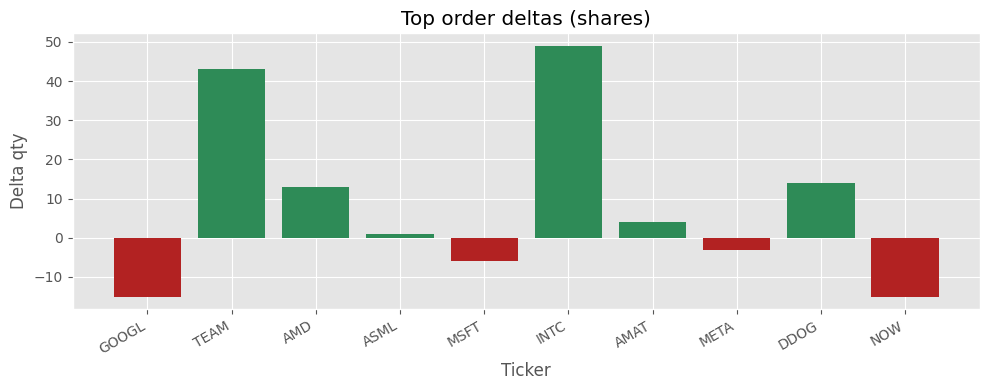

Paper state timestamp: 2026-02-22T15:04:18+00:00
Paper cash: 3601.7249450683594


,ticker,avg_cost,quantity
16,ORCL,156.589996,100.0
17,PANW,166.000000,79.0
0,AAPL,274.619995,61.0
7,GOOGL,324.320007,38.0
6,DDOG,114.010002,34.0
14,NOW,103.870003,32.0
11,MSFT,412.658142,23.0
20,TSM,355.410004,21.0
2,AMZN,208.720001,14.0
21,ZS,170.179993,12.0


In [11]:
exec_dir = ROOT / 'outputs/execution'
summary_files = sorted(exec_dir.glob('*_summary.json'))
orders_files = sorted(exec_dir.glob('*_orders.csv'))

if not summary_files:
    print('No hay summaries de rebalance en outputs/execution.')
else:
    latest_summary_path = summary_files[-1]
    with latest_summary_path.open('r', encoding='utf-8') as fh:
        latest_summary = json.load(fh)
    print('Latest summary:', latest_summary_path.name)
    display(pd.DataFrame([latest_summary]).T.rename(columns={0: 'value'}))

if not orders_files:
    print('No hay order plans en outputs/execution.')
else:
    latest_orders_path = orders_files[-1]
    orders = pd.read_csv(latest_orders_path)
    print('Latest orders:', latest_orders_path.name)
    display(orders.head(20))
    if not orders.empty and 'abs_weight_change' in orders.columns:
        top_orders = orders.sort_values('abs_weight_change', ascending=False).head(10)
    else:
        top_orders = orders.head(10)

    if not top_orders.empty and 'delta_qty' in top_orders.columns:
        colors = top_orders['delta_qty'].apply(lambda x: '#2E8B57' if x > 0 else '#B22222')
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(top_orders['ticker'], top_orders['delta_qty'], color=colors)
        ax.set_title('Top order deltas (shares)')
        ax.set_ylabel('Delta qty')
        ax.set_xlabel('Ticker')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

paper_state = exec_dir / 'paper_state.json'
if paper_state.exists():
    with paper_state.open('r', encoding='utf-8') as fh:
        state = json.load(fh)
    positions = state.get('positions', {})
    pos_df = pd.DataFrame([
        {'ticker': k, **v} for k, v in positions.items()
    ])
    print('Paper state timestamp:', state.get('last_updated'))
    print('Paper cash:', state.get('cash'))
    if not pos_df.empty:
        display(pos_df.sort_values('quantity', ascending=False).head(15))
else:
    print('No existe paper_state.json aun.')
